### **NIH Chest X-ray Disease Classification**

Built a multi-label chest X-ray disease classification system using **ResNet50 transfer learning** and TensorFlow/Keras on a patient-level subset of the NIH Chest X-ray14 dataset. Implemented patient-wise train/validation/test splitting to prevent data leakage, image preprocessing, weighted binary cross-entropy to address severe class imbalance, and checkpointing based on validation AUC.


Evaluated the model using **multi-label ROC-AUC**, achieving a **0.712 test AUC**. Additionally, implemented **Grad-CAM** to visualize image regions contributing to individual disease predictions and improve model interpretability.


In [ ]:
'''
  15 classes: 14 diseases + 1 for No findings
  images: 112,120 (1024 x 1024)
  => single image can have multiple classes at once
'''

In [43]:
!pip install -q datasets

In [44]:
from datasets import load_dataset
import numpy as np
import tensorflow as tf

In [45]:
dataset = load_dataset(
    "chehablab/NIHChestXR",
    split="train",
    streaming=True
)

In [46]:
sample = next(iter(dataset))

print(sample.keys())

dict_keys(['patient_id', 'scan_id', 'image', 'age', 'sex', 'labels'])


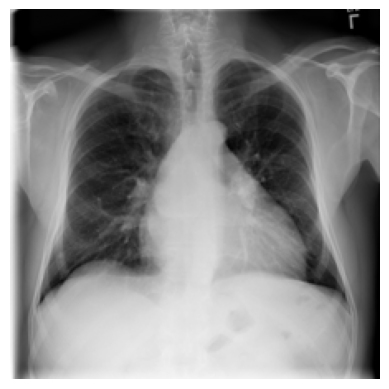

In [47]:
import matplotlib.pyplot as plt

plt.imshow(sample["image"], cmap="gray")
plt.axis("off")
plt.show()

In [48]:
for i, sample in enumerate(dataset):
  print(sample["labels"])

  if i == 9:
    break

[2]
[2, 11]
[2, 3]
[0]
[14]
[14]
[14]
[14, 4]
[14]
[14]


In [49]:
dataset.info.features

{'patient_id': Value('string'),
 'scan_id': Value('int32'),
 'image': Image(mode=None, decode=True),
 'age': Value('int32'),
 'sex': Value('string'),
 'labels': List(Value('int32'))}

In [50]:
dataset = load_dataset(
    "chehablab/NIHChestXR",
    split="train",
    streaming=True
)

count = {}

for sample in dataset:
  for label in sample["labels"]:
    if label in count:
      count[label] += 1
    else:
      count[label] = 1

for label, count in count.items():
  print(f"{label}: {count}")

2: 2776
11: 2516
3: 13317
0: 60361
14: 227
4: 19894
5: 5782
6: 6331
1: 11559
8: 5302
13: 3385
7: 1431
12: 1686
10: 2303
9: 4667


In [ ]:
'''
trying a new thing
using a smaller dataset the og one was apprx 112k
'''

In [51]:
from collections import defaultdict

patient_data = defaultdict(list)

for sample in dataset:
    patient_id = sample["patient_id"]
    labels = sample["labels"]

    patient_data[patient_id].append(labels)

print("Number of patients:", len(patient_data))

Number of patients: 30805


In [52]:
patient_image_counts = {
    patient_id: len(images)
    for patient_id, images in patient_data.items()
}

print("Total patients:", len(patient_image_counts))
print("Total images:", sum(patient_image_counts.values()))

Total patients: 30805
Total images: 112120


In [53]:
import random

random.seed(42)

TARGET_IMAGES = 20000

# Count how many images each patient has
patient_ids = list(patient_data.keys())

# Give each patient the set of classes appearing in their images
patient_classes = {
    patient_id: set(label for labels in images for label in labels)
    for patient_id, images in patient_data.items()
}

# Start by prioritizing patients containing rare classes
class_counts = {
    label: count
    for label, count in {
        0: 60361,
        1: 11559,
        2: 2776,
        3: 13317,
        4: 19894,
        5: 5782,
        6: 6331,
        7: 1431,
        8: 5302,
        9: 4667,
        10: 2303,
        11: 2516,
        12: 1686,
        13: 3385,
        14: 227
    }.items()
}

# Rarest classes get higher priority
class_priority = {
    label: 1 / count
    for label, count in class_counts.items()
}

def patient_priority(patient_id):
    classes = patient_classes[patient_id]

    # Higher score = more useful patient
    return sum(class_priority[c] for c in classes)

# Shuffle first so patients with equal scores are random
random.shuffle(patient_ids)

# Sort patients by usefulness for rare classes
patient_ids.sort(
    key=patient_priority,
    reverse=True
)

selected_patients = []
selected_images = 0

for patient_id in patient_ids:

    n_images = patient_image_counts[patient_id]

    if selected_images + n_images <= TARGET_IMAGES:

        selected_patients.append(patient_id)
        selected_images += n_images

    if selected_images >= TARGET_IMAGES * 0.98:
        break

print("Selected patients:", len(selected_patients))
print("Selected images:", selected_images)

Selected patients: 661
Selected images: 19612


In [54]:
selected_class_counts = {}

for patient_id in selected_patients:

    for labels in patient_data[patient_id]:

        for label in labels:

            selected_class_counts[label] = (
                selected_class_counts.get(label, 0) + 1
            )

for label in sorted(selected_class_counts):
    print(label, ":", selected_class_counts[label])

0 : 6324
1 : 2393
2 : 792
3 : 3747
4 : 5899
5 : 1363
6 : 1311
7 : 689
8 : 1848
9 : 1793
10 : 1047
11 : 853
12 : 444
13 : 966
14 : 227


In [55]:
import random

random.seed(42)

patients = selected_patients.copy()
random.shuffle(patients)

n = len(patients)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_patients = set(patients[:train_end])
val_patients = set(patients[train_end:val_end])
test_patients = set(patients[val_end:])

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))

print("\nTotal:", len(train_patients) + len(val_patients) + len(test_patients))

Train patients: 462
Validation patients: 99
Test patients: 100

Total: 661


In [56]:
train_images = sum(
    patient_image_counts[p]
    for p in train_patients
)

val_images = sum(
    patient_image_counts[p]
    for p in val_patients
)

test_images = sum(
    patient_image_counts[p]
    for p in test_patients
)

print("Train images:", train_images)
print("Validation images:", val_images)
print("Test images:", test_images)
print("Total images:", train_images + val_images + test_images)

Train images: 13823
Validation images: 2972
Test images: 2817
Total images: 19612


In [57]:
num_classes = 15

def multi_hot(labels):
  vector = np.zeros(num_classes, dtype=np.float32)

  for label in labels:
    vector[label] = 1.0

  return vector

In [58]:
import cv2
import numpy as np
import tensorflow as tf

IMG_SIZE = (244, 244)

def preprocess_image(image):
  image = np.array(image)

  image = cv2.resize(image, IMG_SIZE)

  if len(image.shape) == 2:
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

  image = image.astype(np.float32)

  image = tf.keras.applications.resnet50.preprocess_input(image)

  return image

In [59]:
BATCH_SIZE = 32

def data_generator(dataset, patient_set):

  while True:
    images = []
    labels = []

    for sample in dataset:

      patient = sample["patient_id"]

      if patient not in patient_set:
        continue

      image = preprocess_image(sample["image"])
      label = multi_hot(sample["labels"])

      images.append(image)
      labels.append(label)

      if len(images) == BATCH_SIZE:

        yield np.array(images), np.array(labels)

        images = []
        labels = []

    if len(images) > 0:
      yield np.array(images), np.array(labels)

In [60]:
STEPS_PER_EPOCH = train_images // BATCH_SIZE
VALIDATION_STEPS = val_images // BATCH_SIZE
TEST_STEPS = test_images // BATCH_SIZE

print(STEPS_PER_EPOCH)
print(VALIDATION_STEPS)
print(TEST_STEPS)

431
92
88


In [61]:
train_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(dataset, train_patients),
    output_signature=(
        tf.TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 15), dtype=tf.float32)
    )
)

val_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(dataset, val_patients),
    output_signature=(
        tf.TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 15), dtype=tf.float32)
    )
)

test_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(dataset, test_patients),
    output_signature=(
        tf.TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 15), dtype=tf.float32)
    )
)

In [62]:
images, labels = next(iter(train_tf))

print("Images shape: ", images.shape)
print("Labels shape: ", labels.shape)
print("Image dtype: ", images.dtype)
print("Label dtype: ", labels.dtype)

Images shape:  (32, 244, 244, 3)
Labels shape:  (32, 15)
Image dtype:  <dtype: 'float32'>
Label dtype:  <dtype: 'float32'>


In [63]:
import numpy as np

positive_counts = np.zeros(15)
negative_counts = np.zeros(15)

for patient_id in train_patients:
    for labels in patient_data[patient_id]:

        for label in range(15):
            if label in labels:
                positive_counts[label] += 1
            else:
                negative_counts[label] += 1

pos_weights = negative_counts / positive_counts

print("Positive counts:", positive_counts)
print("Positive weights:", pos_weights)

Positive counts: [4355. 1710.  598. 2722. 4236.  964.  913.  503. 1283. 1310.  791.  538.
  315.  647.  161.]
Positive weights: [ 2.17405281  7.08362573 22.11538462  4.07825129  2.26322002 13.33921162
 14.14019715 26.48111332  9.77396726  9.5519084  16.47534766 24.69330855
 42.88253968 20.36476043 84.85714286]


In [64]:
# weighted Binary Cross Entropy (BCE)
def weighted_bce(y_true, y_pred):
  bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

  weights = y_true * pos_weights + (1 - y_true)
  weighted_loss = bce * weights

  return tf.reduce_mean(weighted_loss)

In [24]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(244, 244, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(244, 244, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(
    15,
    activation = "sigmoid"
)(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        30,735 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=weighted_bce,
    metrics=[
        tf.keras.metrics.AUC(
            multi_label=True,
            num_labels=15,
            name="auc"
        )
    ]
)

In [33]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/best_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True
)

In [46]:
history = model.fit(
    train_tf,
    validation_data=val_tf,
    epochs=5,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=[checkpoint]
)

Epoch 1/5
431/431 ━━━━━━━━━━━━━━━━━━━━ 364s 837ms/step - auc: 0.6947 - loss: 1.1160 - val_auc: 0.6597 - val_loss: 1.1536
Epoch 2/5
431/431 ━━━━━━━━━━━━━━━━━━━━ 366s 851ms/step - auc: 0.7036 - loss: 1.1032 - val_auc: 0.6633 - val_loss: 1.1495
Epoch 3/5
431/431 ━━━━━━━━━━━━━━━━━━━━ 364s 846ms/step - auc: 0.7112 - loss: 1.0928 - val_auc: 0.6662 - val_loss: 1.1466
Epoch 4/5
431/431 ━━━━━━━━━━━━━━━━━━━━ 364s 846ms/step - auc: 0.7180 - loss: 1.0820 - val_auc: 0.6683 - val_loss: 1.1445
Epoch 5/5
431/431 ━━━━━━━━━━━━━━━━━━━━ 362s 843ms/step - auc: 0.7232 - loss: 1.0744 - val_auc: 0.6703 - val_loss: 1.1428


In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/best_model.keras",
    custom_objects={"weighted_bce": weighted_bce}
)

In [67]:
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        30,735 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,679,919 (90.33 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 61,472 (240.13 KB)

In [68]:
# checking if the best model is loaded
best_model.optimizer.learning_rate.numpy()

np.float32(1e-04)

In [69]:
import os

print(os.path.exists("/content/drive/MyDrive/best_model.keras"))

True


In [70]:
# evluating on test results now
test_results = best_model.evaluate(
    test_tf,
    steps=TEST_STEPS,
    return_dict=True
)

print(test_results)

88/88 ━━━━━━━━━━━━━━━━━━━━ 800s 9s/step - auc: 0.7122 - loss: 1.1078
{'auc': 0.7121949791908264, 'loss': 1.1077936887741089}


In [71]:
for layer in best_model.layers:
  print(layer.name, layer.output.shape)

input_layer_1 (None, 244, 244, 3)
resnet50 (None, 8, 8, 2048)
global_average_pooling2d (None, 2048)
dense (None, 15)


In [74]:
base_model = best_model.get_layer("resnet50")

for layer in base_model.layers[-20:]:
  print(layer.name, layer.__class__.__name__)

conv5_block2_1_conv Conv2D
conv5_block2_1_bn BatchNormalization
conv5_block2_1_relu Activation
conv5_block2_2_conv Conv2D
conv5_block2_2_bn BatchNormalization
conv5_block2_2_relu Activation
conv5_block2_3_conv Conv2D
conv5_block2_3_bn BatchNormalization
conv5_block2_add Add
conv5_block2_out Activation
conv5_block3_1_conv Conv2D
conv5_block3_1_bn BatchNormalization
conv5_block3_1_relu Activation
conv5_block3_2_conv Conv2D
conv5_block3_2_bn BatchNormalization
conv5_block3_2_relu Activation
conv5_block3_3_conv Conv2D
conv5_block3_3_bn BatchNormalization
conv5_block3_add Add
conv5_block3_out Activation


In [76]:
last_conv_layer = best_model.get_layer("resnet50").get_layer(
    "conv5_block3_out"
)

In [81]:
def make_gradcam_heatmap(img_array, model, class_index):

    base_model = model.get_layer("resnet50")
    gap_layer = model.get_layer("global_average_pooling2d")
    dense_layer = model.get_layer("dense")

    with tf.GradientTape() as tape:

        # Get ResNet feature maps
        conv_outputs = base_model(img_array, training=False)

        # Keep the graph connected to the final prediction
        x = gap_layer(conv_outputs)
        predictions = dense_layer(x)

        # Select the class we want
        class_output = predictions[:, class_index]

    # Gradient of class prediction with respect to feature maps
    grads = tape.gradient(
        class_output,
        conv_outputs
    )

    # Average gradients across height and width
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight each feature map by its importance
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Keep only positive influence
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

In [87]:
# Find a disease-positive sample from our selected test subset
disease_sample = None

for sample in dataset:
    patient_id = sample["patient_id"]

    if patient_id in test_patients:
        # Ignore No Finding-only images
        disease_labels = [x for x in sample["labels"] if x != 0]

        if len(disease_labels) > 0:
            disease_sample = sample
            break

print("Patient:", disease_sample["patient_id"])
print("True labels:", disease_sample["labels"])

Patient: 13
True labels: [11, 8]


In [88]:
label_names = {
    0: "No Finding",
    1: "Atelectasis",
    2: "Cardiomegaly",
    3: "Effusion",
    4: "Infiltration",
    5: "Mass",
    6: "Nodule",
    7: "Pneumonia",
    8: "Pneumothorax",
    9: "Consolidation",
    10: "Edema",
    11: "Emphysema",
    12: "Fibrosis",
    13: "Pleural Thickening",
    14: "Hernia"
}

print("Diseases:")
for label in disease_sample["labels"]:
    if label != 0:
        print(label, "=", label_names[label])

Diseases:
11 = Emphysema
8 = Pneumothorax


In [89]:
def show_gradcam(sample, class_index):

    # -------------------------
    # Prepare image
    # -------------------------
    img = preprocess_image(sample["image"])
    img_array = np.expand_dims(img, axis=0)

    # -------------------------
    # Prediction
    # -------------------------
    predictions = best_model.predict(
        img_array,
        verbose=0
    )[0]

    # -------------------------
    # Grad-CAM
    # -------------------------
    heatmap = make_gradcam_heatmap(
        img_array,
        best_model,
        class_index
    )

    # -------------------------
    # Original image
    # -------------------------
    original = np.array(sample["image"])
    original = cv2.resize(original, (244, 244))

    if len(original.shape) == 2:
        original = cv2.cvtColor(
            original,
            cv2.COLOR_GRAY2RGB
        )

    if original.max() <= 1.0:
        original = (original * 255).astype(np.uint8)
    else:
        original = original.astype(np.uint8)

    # -------------------------
    # Heatmap
    # -------------------------
    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    heatmap_color = cv2.resize(
        heatmap_color,
        (244, 244)
    )

    # -------------------------
    # Overlay
    # -------------------------
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # -------------------------
    # Display
    # -------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original X-ray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_color)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Class:", class_index)
    print("Probability:", predictions[class_index])

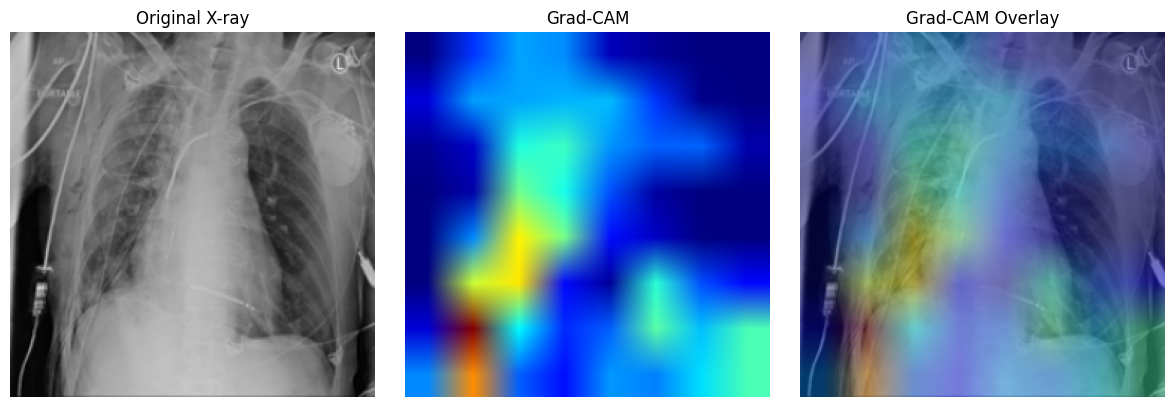

Class: 11
Probability: 0.92758626


In [92]:
show_gradcam(disease_sample, 11)

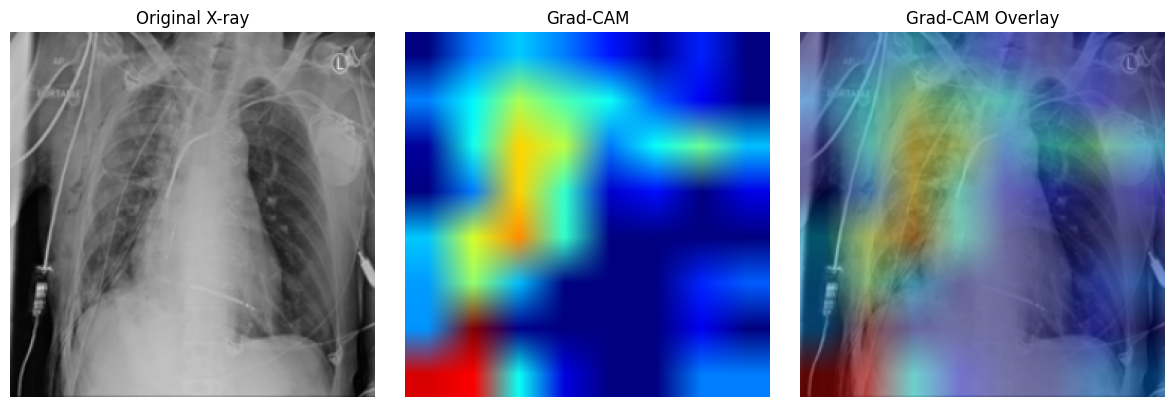

Class: 8
Probability: 0.86097753


In [93]:
show_gradcam(disease_sample, 8)